# Aircraft Flight Data Analysis Using NumPy and Matplotlib

### Objective
Analyze aircraft flight-test data using **NumPy** for numerical processing and **Matplotlib** for visualization.


### Dataset
Use the supplied file:

`aircraft_flight_data.csv`

The dataset contains 150 measurements sampled every 5 seconds with:

- `time` — time in seconds
- `altitude` — altitude in meters
- `airspeed` — airspeed in m/s
- `rpm` — engine speed in revolutions per minute


## Exercise Load and Inspect the Data 

Using NumPy:

1. Load the CSV file. use `data = np.loadtxt(
    "<file_name.csv>",
    delimiter=",",
    skiprows=1
)`
2. Store `time`, `altitude`, `airspeed`, and `rpm` as separate NumPy arrays.
3. Display:
   - Number of measurements
   - Shape of the arrays
   - Minimum and maximum altitude
   - Minimum and maximum airspeed
   - Average RPM

### Your code


In [28]:
import numpy as np

data = np.loadtxt("aircraft_flight_data.csv", delimiter=",", skiprows=1)
time = data[:, 0]
altitude = data[:, 1]
airspeed = data[:, 2]
rpm = data[:, 3]


print(f"""
Measurements {len(time)}

Shapes: 
    Time {time.shape}
    Altitude {altitude.shape}
    Airspeed {airspeed.shape}
    RPM {rpm.shape}

Min Altitude: {np.min(altitude):.2f}, Max Altitude: {np.max(altitude):.2f}
Min Airspeed: {np.min(airspeed):.2f}, Max Airspeed: {np.max(airspeed):.2f} 
Avg RPM {np.mean(rpm):.2f}
""")



Measurements 150

Shapes: 
    Time (150,)
    Altitude (150,)
    Airspeed (150,)
    RPM (150,)

Min Altitude: 1000.80, Max Altitude: 2181.50
Min Airspeed: 57.90, Max Airspeed: 87.10 
Avg RPM 2406.35



## Calculate Flight Parameters

Calculate the following using NumPy.

### A. Rate of Climb

Use:

$ROC = \frac{\Delta h}{\Delta t}$

Store the result in a NumPy array called `roc`.

### B. Airspeed Acceleration

Use:

$a = \frac{\Delta V}{\Delta t}$

Store the result in an array called `acceleration`.

### C. RPM Deviation

Calculate:

$RPM_{dev}=RPM-RPM_{avg}$

Store the result in an array called `rpm_deviation`.

### Requirements
- Use NumPy for all calculations.
- Use `np.diff(array_name)` to calculate the difference between consecutive elements of an array.
- Do not use a Python for loop for any of the above calculations.
- Note that roc and acceleration will contain one fewer element than the original data arrays because they are calculated from consecutive measurements.

In [29]:
dh = np.diff(altitude)
dt = np.diff(time)
roc = dh/dt

dv = np.diff(airspeed)
acceleration = dv/dt

rpm_deviation = rpm - np.mean(rpm)

## Statistical Analysis 

Using NumPy, determine:

1. Mean altitude
2. Median altitude
3. Standard deviation of altitude
4. Mean airspeed
5. Standard deviation of airspeed
6. Maximum rate of climb
7. Minimum rate of climb
8. Time at which the maximum rate of climb occurred
9. Time at which the maximum airspeed occurred

Use appropriate NumPy functions such as:

`np.mean()`, `np.median()`, `np.std()`, `np.max()`, `np.min()`, `np.argmax()`, and `np.argmin()`.

### Your code


In [30]:
mean_alt = np.mean(altitude)
median_alt = np.median(altitude)
std_deviation_alt = np.std(altitude)

mean_as = np.mean(airspeed)
std_deviation_as = np.std(airspeed)
max_roc = np.max(roc)
min_roc = np.min(roc)

index_max_roc = np.argmax(roc)
max_roc_time = time[index_max_roc]

index_max_as = np.argmax(airspeed)
max_as_time = time[index_max_as]


print("""
Mean altitude: {mean_alt}, median altitude: {median_alt}, std deviation of altitude: {std_deviation_alt}
Mean airspeed: {mean_as}, std deviation of airspeed: {std_deviation_as}
max roc: {max_roc}, min roc: {min_roc}
max roc time: {max_roc_time}, max airspeed time: {max_as_time}
""")



Mean altitude: {mean_alt}, median altitude: {median_alt}, std deviation of altitude: {std_deviation_alt}
Mean airspeed: {mean_as}, std deviation of airspeed: {std_deviation_as}
max roc: {max_roc}, min roc: {min_roc}
max roc time: {max_roc_time}, max airspeed time: {max_as_time}



## Detect Flight Conditions

Use NumPy Boolean indexing or `np.where()` to identify:

### A. Climbing
`ROC > 2 m/s`

### B. Descending
`ROC < -2 m/s`

### C. High-speed condition
`airspeed > 80 m/s`

### D. High-RPM condition
`rpm > 2500`

For each condition, determine:

- Number of measurements
- Percentage of total measurements
- First time the condition occurs
- Last time the condition occurs

**Note:** `roc` has one fewer element than `time` because it represents the change between consecutive measurements. Use the appropriate time array when analyzing ROC.


In [31]:
def print_condition_stats(condition_name, mask, time_array):
    num_measurements = np.sum(mask)
    total_measurements = len(time_array)

    print(f"\n--- {condition_name} ---")
    print(f"Number of measurements: {num_measurements}")
    if total_measurements > 0:
        percentage = (num_measurements / total_measurements) * 100
        print(f"Percentage of total measurements: {percentage:.2f}%")
    else:
        print("Percentage of total measurements: 0.00%")

    if num_measurements > 0:
        first_time = time_array[mask][0]
        last_time = time_array[mask][-1]
        print(f"First time occurred: {first_time:.2f} seconds")
        print(f"Last time occurred: {last_time:.2f} seconds")
    else:
        print("First time occurred: N/A")
        print("Last time occurred: N/A")


# A. Climbing (ROC > 2 m/s)
climbing_mask = roc > 2
# ROC is one element shorter than time, so we use time[1:] for ROC-related time analysis
print_condition_stats("Climbing (ROC > 2 m/s)", climbing_mask, time[1:])

# B. Descending (ROC < -2 m/s)
descending_mask = roc < -2
print_condition_stats("Descending (ROC < -2 m/s)", descending_mask, time[1:])

# C. High-speed condition (airspeed > 80 m/s)
high_speed_mask = airspeed > 80
print_condition_stats("High-speed condition (airspeed > 80 m/s)", high_speed_mask, time)

# D. High-RPM condition (rpm > 2500)
high_rpm_mask = rpm > 2500
print_condition_stats("High-RPM condition (rpm > 2500)", high_rpm_mask, time)


--- Climbing (ROC > 2 m/s) ---
Number of measurements: 79
Percentage of total measurements: 53.02%
First time occurred: 10.00 seconds
Last time occurred: 450.00 seconds

--- Descending (ROC < -2 m/s) ---
Number of measurements: 17
Percentage of total measurements: 11.41%
First time occurred: 555.00 seconds
Last time occurred: 650.00 seconds

--- High-speed condition (airspeed > 80 m/s) ---
Number of measurements: 66
Percentage of total measurements: 44.00%
First time occurred: 410.00 seconds
Last time occurred: 745.00 seconds

--- High-RPM condition (rpm > 2500) ---
Number of measurements: 39
Percentage of total measurements: 26.00%
First time occurred: 340.00 seconds
Last time occurred: 560.00 seconds


## Basic Visualization

Create follwing  **Matplotlib figures** containing:

1. Altitude vs Time
2. Airspeed vs Time
3. Rate of Climb vs Time
4. RPM vs Time

Each plot must include:

- Appropriate title
- X-axis label
- Y-axis label
- Units
- Grid
- Legend where appropriate

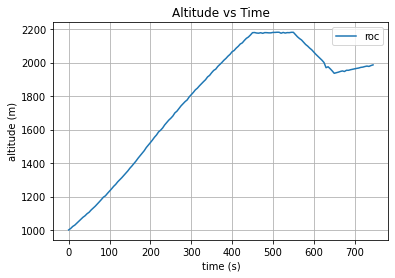

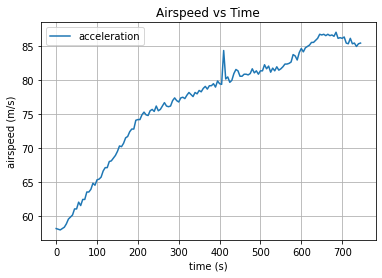

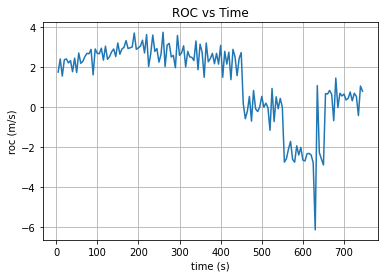

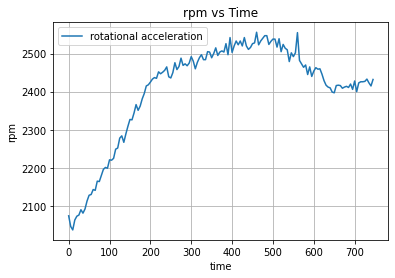

In [32]:
import matplotlib.pyplot as plt

plt.plot(time, altitude, label='roc')
plt.title('Altitude vs Time')
plt.xlabel('time (s)')
plt.ylabel('altitude (m)')
plt.legend()
plt.grid()
plt.show()


plt.plot(time, airspeed, label='acceleration')
plt.title('Airspeed vs Time')
plt.xlabel('time (s)')
plt.ylabel('airspeed (m/s)')
plt.legend()
plt.grid()
plt.show()

plt.plot(time[1:], roc)
plt.title('ROC vs Time')
plt.xlabel('time (s)')
plt.ylabel('roc (m/s)')
# plt.legend()
plt.grid()
plt.show()

plt.plot(time, rpm, label="rotational acceleration")
plt.title('rpm vs Time')
plt.xlabel('time')
plt.ylabel('rpm')
plt.legend()
plt.grid()
plt.show()



# Submission Checklist

Before submitting, ensure that:

* [ ] The notebook runs without errors.
* [ ] NumPy is used for calculations; Pandas is not used.
* [ ] Matplotlib is used for visualization.
* [ ] All required tasks are completed.
* [ ] The correct CSV file name is used.
* [ ] All outputs and plots are visible.
* [ ] You can explain and modify your own code when asked.
